# Outlier Detection using Standard Deviation & Z-score

In [1]:
# extreme values
# sticks out of range

In [2]:
import seaborn as sns

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
data = pd.read_csv("C:/Users/Administrator/Downloads/weight-height.csv")   

In [5]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
data.shape

(10000, 3)

In [7]:
data.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


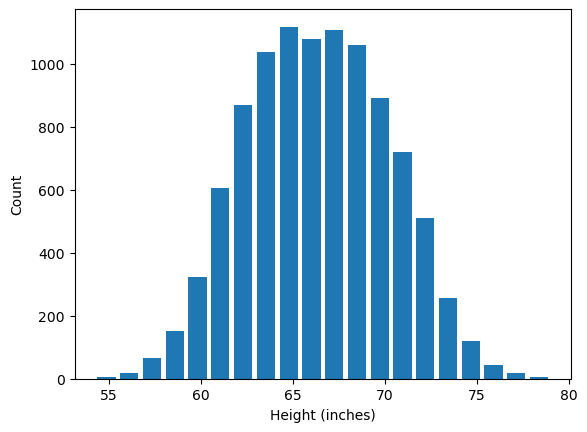

In [8]:
plt.hist(data['Height'],bins=20,rwidth=0.8)
plt.xlabel('Height (inches)')
plt.ylabel('Count')
plt.show()

In [9]:
data['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

# Outlier Removal using Std Dev

In [10]:
standard_deviation = data['Height'].std()
mean = data['Height'].mean()

standard_deviation,mean

(3.8475281207732324, np.float64(66.36755975482124))

In [11]:
Upper_limit = mean + (3*standard_deviation)
Lower_limit = mean - (3*standard_deviation)
print(Upper_limit)
print(Lower_limit)

77.91014411714094
54.82497539250154


In [12]:
mask = (data['Height']<Lower_limit) | (data['Height']>Upper_limit)


In [13]:
#a = np.array([[1,2,3],[4,5,6],[7,8,9]])

In [14]:
#a

In [15]:
#a[(a>3) & (a<7)]

In [16]:
mask

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Height, Length: 10000, dtype: bool

In [17]:
data[mask]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [18]:
data[mask].shape

(7, 3)

In [19]:
mask1 = (data['Height']>=Lower_limit) & (data['Height']<=Upper_limit)
data[mask1]

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [20]:
#new_df

In [21]:
data[mask1].shape

(9993, 3)

# Outlier Removal using IQR

In [22]:
q1 = np.quantile(data['Height'],0.25)
q3 = np.quantile(data['Height'],0.75)
IQR = q3-q1

In [23]:
Upper_limitIQR = q3 + (1.5*IQR)
Lower_limitIQR = q1 - (1.5*IQR)
print(Upper_limit)
print(Lower_limit)

77.91014411714094
54.82497539250154


In [31]:
mask1 = (data['Height']<=Lower_limitIQR) | (data['Height']>=Upper_limitIQR)
data[mask1]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127


In [32]:
data[mask1].shape

(8, 3)

In [35]:
mask2 = (data['Height']>=Lower_limitIQR) & (data['Height']<=Upper_limitIQR)
data[mask2]

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [36]:
data[mask2].shape

(9992, 3)


# Outlier Removal using Z-score

In [20]:
def z_score(df,column):
    x = df[column].values #data['Height']
    mean = df[column].mean()
    standard_deviation = df[column].std()
    return (x-mean) / standard_deviation

In [21]:
data['z score'] = z_score(data,'Height')

In [22]:
data.head()

,Gender,Height,Weight,z score
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [23]:
mask = (data['z score']<-3) | (data['z score']>3)
data[mask]

,Gender,Height,Weight,z score
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [24]:
data[mask].shape

(7, 4)

In [25]:
mask1 = (data['z score']>-3) & (data['z score']<3)
new_df = data[mask1]

In [26]:
new_df.shape

(9993, 4)

# Data Preprocessing in Data Mining

In [27]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler, Normalizer, Binarizer

In [28]:
df1 = pd.read_csv('C:\\Users\\winequalityN.csv', usecols = ['fixed acidity','residual sugar'])

In [29]:
df1.head()

,fixed acidity,residual sugar
0,7.0,20.7
1,6.3,1.6
2,8.1,6.9
3,7.2,8.5
4,7.2,8.5


In [30]:
df1.describe()

,fixed acidity,residual sugar
count,6487.000000,6495.000000
mean,7.216579,5.444326
std,1.296750,4.758125
min,3.800000,0.600000
25%,6.400000,1.800000
50%,7.000000,3.000000
75%,7.700000,8.100000
max,15.900000,65.800000


In [31]:
#MinMaxScaler
m_scaler = MinMaxScaler()
scaled_data = m_scaler.fit_transform(df1.dropna())
scaled_data

array([[0.26446281, 0.30828221],
       [0.20661157, 0.01533742],
       [0.3553719 , 0.09662577],
       ...,
       [0.20661157, 0.02607362],
       [0.17355372, 0.02147239],
       [0.18181818, 0.04601227]])

In [32]:
s_scaler = StandardScaler()
scaled_data = s_scaler.fit_transform(df1.dropna())
scaled_data

array([[-0.1671114 ,  3.2069093 ],
       [-0.70690732, -0.80787363],
       [ 0.68113933,  0.30617608],
       ...,
       [-0.70690732, -0.66073499],
       [-1.01536213, -0.72379441],
       [-0.93824843, -0.38747751]])

In [33]:
normalizer = Normalizer()
scaled_data = normalizer.fit_transform(df1.dropna())
scaled_data

array([[0.32034349, 0.94730146],
       [0.96923077, 0.24615385],
       [0.76124323, 0.64846646],
       ...,
       [0.93935732, 0.34293997],
       [0.94706588, 0.32103928],
       [0.85749293, 0.51449576]])

In [34]:
binarizer = Binarizer()
scaled_data = binarizer.fit_transform(df1.dropna())
scaled_data

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       ...,
       [1., 1.],
       [1., 1.],
       [1., 1.]])

In [36]:
df2 = pd.read_csv('C:\\Users\\StudentsPerformance.csv', usecols = ['gender','math score'])

In [37]:
df2.head()

,gender,math score
0,female,72
1,female,69
2,female,90
3,male,47
4,male,76


In [38]:
#define the bins
bins = [0,25,50,75,100]

#deine the bin names
bin_names = ['Fail','Average','Good','Brilliant']

df2['Grades'] = pd.cut(df2['math score'], bins = bins,labels = bin_names)

In [39]:
df2

,gender,math score,Grades
0,female,72,Good
1,female,69,Good
2,female,90,Brilliant
3,male,47,Average
4,male,76,Brilliant
...,...,...,...
995,female,88,Brilliant
996,male,62,Good
997,female,59,Good
998,female,68,Good


In [40]:
import seaborn as sns

In [42]:
df = sns.load_dataset('tips')

In [43]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [44]:
df.shape

(244, 7)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [47]:
#using pd.get_dummies()--> one hot encoding
df1 = pd.get_dummies(df, columns = ['sex', 'smoker'], drop_first=True)

In [48]:
df1.head()

,total_bill,tip,day,time,size,sex_Female,smoker_No
0,16.99,1.01,Sun,Dinner,2,True,True
1,10.34,1.66,Sun,Dinner,3,False,True
2,21.01,3.50,Sun,Dinner,3,False,True
3,23.68,3.31,Sun,Dinner,2,False,True
4,24.59,3.61,Sun,Dinner,4,True,True


In [49]:
from sklearn.preprocessing import LabelEncoder

In [50]:
le = LabelEncoder()
le.fit_transform(df["sex"])

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0])

In [51]:
le = LabelEncoder()
le.fit_transform(df["smoker"])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0])

In [52]:
le = LabelEncoder()
le.fit_transform(df["day"])

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3])

In [53]:
df["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [54]:
le.classes_

array(['Fri', 'Sat', 'Sun', 'Thur'], dtype=object)